In [10]:
from pynq import Overlay, allocate
import numpy as np
import time

ol = Overlay("design_1_wrapper.bit")
ol.download()

print(ol.ip_dict.keys())   # sanity
dma = ol.DMA               # since your block is named "DMA"
print(dma)


dict_keys(['sobel_hw_stream_0', 'DMA', 'processing_system7_0'])


In [16]:

WIDTH, HEIGHT = 256, 256
N = WIDTH*HEIGHT

img = np.zeros((256,256), dtype=np.uint8)
np.fill_diagonal(img, 255)


in_buf  = allocate(shape=(N,), dtype=np.uint8)
out_buf = allocate(shape=(N,), dtype=np.uint8)

in_buf[:] = img.flatten()
out_buf[:] = 0


In [17]:
print(ol.ip_dict.keys())
sobel = ol.sobel_hw_stream_0   # or whatever exact name shows up
print(sobel.register_map)

sobel.write(0x00, 0x01)  # ap_start = 1


dict_keys(['sobel_hw_stream_0', 'DMA', 'processing_system7_0'])
RegisterMap {
  CTRL = Register(AP_START=0, AP_DONE=0, AP_IDLE=1, AP_READY=0, RESERVED_1=0, AUTO_RESTART=0, RESERVED_2=0),
  GIER = Register(Enable=0, RESERVED=0),
  IP_IER = Register(CHAN0_INT_EN=0, CHAN1_INT_EN=0, RESERVED=0),
  IP_ISR = Register(CHAN0_INT_ST=0, CHAN1_INT_ST=0, RESERVED=0)
}


In [21]:
in_buf.flush()
out_buf.flush()

sobel.write(0x00, 0x81)  # start + auto restart

dma.recvchannel.transfer(out_buf)
dma.sendchannel.transfer(in_buf)

dma.recvchannel.wait()
dma.sendchannel.wait()

out_buf.invalidate()
out_img = np.array(out_buf).reshape((HEIGHT, WIDTH))


In [22]:
out_img = np.array(out_buf).reshape((HEIGHT, WIDTH))
print(out_img.min(), out_img.max(), out_img.mean())


0 255 3.929901123046875


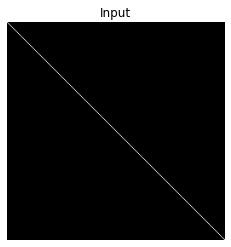

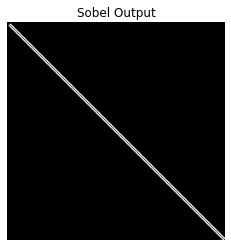

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(img, cmap="gray")
plt.title("Input")
plt.axis("off")

plt.figure()
plt.imshow(out_img, cmap="gray")
plt.title("Sobel Output")
plt.axis("off")
plt.show()
